In [2]:
import pandas as pd
import seaborn as sns
import matplotlib
matplotlib.use("Agg") 
%matplotlib inline
import matplotlib.pyplot as plt
import argparse  
import sqlite3
from threading import Thread

cnx = sqlite3.connect('./data_copy.db')
try:
    cnx.execute('''
            CREATE INDEX IF NOT EXISTS idx_elasticity_lookup 
            ON data (experiment, provider, date_time, language, cpu, memory, timestamp)
    ''')
    cnx.commit()
    print("Index created/verified")
except Exception as e:
    print(f"Index creation note: {e}")

Index created/verified


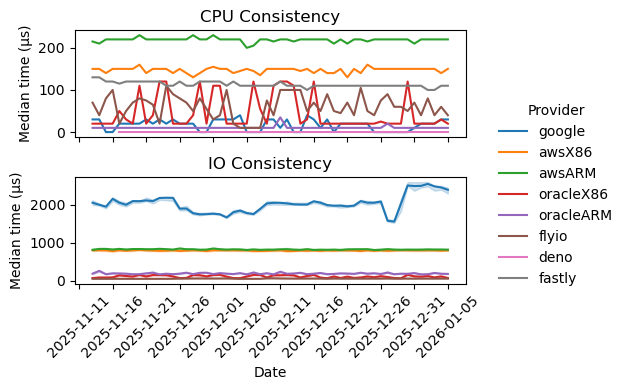

,median,p99,p95,p75,p25,iqr
awsARM,220.0,300.0,280.0,240.0,20.0,220.0
awsX86,150.0,200.0,190.0,170.0,20.0,150.0
deno,0.0,2000.0,0.0,0.0,0.0,0.0
fastly,110.0,180.0,160.0,130.0,90.0,40.0
flyio,20.0,250.0,180.0,130.0,10.0,120.0
google,20.0,150.0,50.0,30.0,0.0,30.0
oracleARM,10.0,240.0,210.0,20.0,10.0,10.0
oracleX86,20.0,380.0,200.0,140.0,20.0,120.0
ALL,20.0,245.0,185.0,130.0,15.0,80.0


,median,p99,p95,p75,p25,iqr
awsARM,822.145,1034.6287,985.0720,898.9125,751.1875,147.7250
awsX86,795.510,920.7452,899.9100,840.9200,737.5250,103.3950
flyio,49.710,127.5125,86.0050,56.8350,44.9200,11.9150
google,2002.180,3109.0632,2712.0770,2207.5650,1806.8000,400.7650
oracleARM,183.820,370.0390,302.6790,245.7750,146.8050,98.9700
oracleX86,105.140,365.4026,224.6360,164.9250,62.2350,102.6900
ALL,489.665,645.3921,601.2945,543.3475,442.1650,103.0425


In [ ]:
# CPU + IO performance over time (stacked, shared x-axis)
from pathlib import Path
import json
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from IPython.display import display

def _safe_name(text: str) -> str:
    return text.replace(" ", "_").replace("/", "-").replace("+", "plus").lower()

# Define the providers you want to plot
providers = ["google", "awsX86", "awsARM", "oracleX86", "oracleARM", "flyio", "deno", "fastly"]  # <-- edit this list

config_path = Path("config") / "provider_config.json"
with config_path.open("r", encoding="utf-8") as f:
    provider_config = json.load(f)

provider_labels = provider_config["provider_labels"]
provider_palette = provider_config["provider_palette"]
provider_linestyles = provider_config.get("provider_linestyles", {})

_dash_lookup = {
    "solid": (),
    "dashed": (4, 2),
    "dashdot": (4, 2, 1, 2),
    "dotted": (1, 1),
}

def _dash_from_config(value):
    if isinstance(value, list):
        return tuple(value)
    if isinstance(value, tuple):
        return value
    if isinstance(value, str):
        return _dash_lookup.get(value, ())
    return ()

def _legend_linestyle(dashes: tuple):
    return (0, dashes) if dashes else "solid"

dash_map = {
    p: _dash_from_config(provider_linestyles.get(p, "solid"))
    for p in providers
}

# Consistent color mapping across figures
provider_colors = {p: provider_palette.get(p, "#999999") for p in providers}

def _load_experiment_df(experiment: str) -> pd.DataFrame:
    df = pd.read_sql("select * from data where experiment = ?", cnx, params=[experiment])
    df = df[df["provider"].isin(providers)].copy()
    df["date_time"] = pd.to_datetime(df["date_time"].str[0:10])
    # Cap outliers per provider (p99)
    df["p99"] = df.groupby("provider")["time_to_complete"].transform(lambda s: s.quantile(0.99))
    df = df[df["time_to_complete"] <= df["p99"]].drop(columns=["p99"])

    return df

df_cpu = _load_experiment_df("cpu")
df_io = _load_experiment_df("io")

# Use native units (µs)
df_cpu["time_µs"] = df_cpu["time_to_complete"]*1000
df_io["time_µs"] = df_io["time_to_complete"]

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 4), sharex=True)
ax_cpu, ax_io = axes

sns.lineplot(
    data=df_cpu,
    x="date_time",
    y="time_µs",
    hue="provider",
    style="provider",
    dashes=dash_map,
    hue_order=providers,
    style_order=providers,
    palette=provider_colors,
    ax=ax_cpu,
    estimator="median",
    errorbar=None,
 )
ax_cpu.set_title("CPU Consistency")
ax_cpu.set_ylabel("Median time (µs)")
ax_cpu.set_xlabel("")
ax_cpu.tick_params(axis="x", rotation=45)
if ax_cpu.get_legend():
    ax_cpu.get_legend().remove()

sns.lineplot(
    data=df_io,
    x="date_time",
    y="time_µs",
    hue="provider",
    style="provider",
    dashes=dash_map,
    hue_order=providers,
    style_order=providers,
    palette=provider_colors,
    ax=ax_io,
    estimator="median",
    errorbar="ci",
 )
ax_io.set_title("IO Consistency")
ax_io.set_ylabel("Median time (µs)")
ax_io.set_xlabel("Date")
ax_io.tick_params(axis="x", rotation=45)
if ax_io.get_legend():
    ax_io.get_legend().remove()

# X-axis ticks every 5 days
locator = mdates.DayLocator(interval=5)
formatter = mdates.DateFormatter("%Y-%m-%d")
ax_io.xaxis.set_major_locator(locator)
ax_io.xaxis.set_major_formatter(formatter)

# Shared legend on the right (closer to plots)
legend_handles = [
    Line2D([0], [0], color=provider_colors[p], lw=2, linestyle=_legend_linestyle(dash_map.get(p, ())))
    for p in providers
 ]
legend_labels = [provider_labels.get(p, p) for p in providers]
fig.legend(
    legend_handles,
    legend_labels,
    title="Provider",
    loc="center left",
    bbox_to_anchor=(0.82, 0.5),
    frameon=False,
 )

fig.tight_layout(rect=[0, 0, 0.83, 1])
plt.show()

# Summary stats tables (per provider + ALL, equal-weighted across providers)
def _summary_stats(series: pd.Series) -> pd.Series:
    q = series.quantile([0.25, 0.5, 0.75, 0.95, 0.99])
    p25, median, p75, p95, p99 = q.loc[0.25], q.loc[0.5], q.loc[0.75], q.loc[0.95], q.loc[0.99]
    iqr = p75 - p25
    return pd.Series({
        "median": median,
        "p99": p99,
        "p95": p95,
        "p75": p75,
        "p25": p25,
        "iqr": iqr,
    })

def _provider_table(df: pd.DataFrame) -> pd.DataFrame:
    per_provider = df.groupby("provider")["time_µs"].agg(
        median="median",
        p99=lambda s: s.quantile(0.99),
        p95=lambda s: s.quantile(0.95),
        p75=lambda s: s.quantile(0.75),
        p25=lambda s: s.quantile(0.25),
    )
    per_provider["iqr"] = per_provider["p75"] - per_provider["p25"]
    overall = per_provider.median(numeric_only=True).to_frame().T
    overall.index = ["ALL"]
    out = pd.concat([per_provider, overall], axis=0)
    return out

cpu_summary_df = _provider_table(df_cpu)
io_summary_df = _provider_table(df_io)

display(cpu_summary_df)
display(io_summary_df)

# Export camera-ready version (no title)
export_dir = Path("figures") / "04_cpu"
export_dir.mkdir(parents=True, exist_ok=True)
export_path = export_dir / f"cpu_io_latency_all_providers_{_safe_name('daily')}.pdf"
fig.savefig(export_path, bbox_inches="tight")

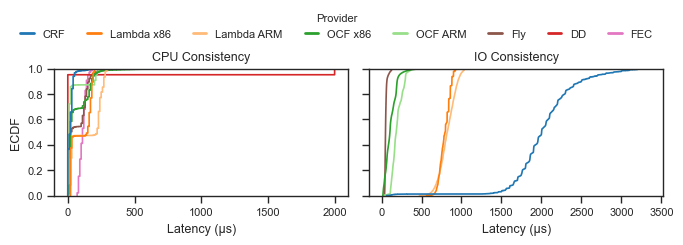

,median,p99,p95,p75,p25,iqr
awsARM,220.0,300.0,280.0,240.0,20.0,220.0
awsX86,150.0,200.0,190.0,170.0,20.0,150.0
deno,0.0,2000.0,0.0,0.0,0.0,0.0
fastly,110.0,180.0,160.0,130.0,90.0,40.0
flyio,20.0,250.0,180.0,130.0,10.0,120.0
google,20.0,150.0,50.0,30.0,0.0,30.0
oracleARM,10.0,240.0,210.0,20.0,10.0,10.0
oracleX86,20.0,380.0,200.0,140.0,20.0,120.0
ALL,20.0,245.0,185.0,130.0,15.0,80.0


,median,p99,p95,p75,p25,iqr
awsARM,822.145,1034.6287,985.0720,898.9125,751.1875,147.7250
awsX86,795.510,920.7452,899.9100,840.9200,737.5250,103.3950
flyio,49.710,127.5125,86.0050,56.8350,44.9200,11.9150
google,2002.180,3109.0632,2712.0770,2207.5650,1806.8000,400.7650
oracleARM,183.820,370.0390,302.6790,245.7750,146.8050,98.9700
oracleX86,105.140,365.4026,224.6360,164.9250,62.2350,102.6900
ALL,489.665,645.3921,601.2945,543.3475,442.1650,103.0425


In [11]:
# CPU + IO latency ECDFs (shared legend, microseconds)
from pathlib import Path
import json
from matplotlib.lines import Line2D

sns.set_theme(
    context="paper",
    style="ticks",
    rc={
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "legend.title_fontsize": 8,
    },
)

def _safe_name(text: str) -> str:
    return text.replace(" ", "_").replace("/", "-").replace("+", "plus").lower()

# Define the providers you want to plot
providers = ["google", "awsX86", "awsARM", "oracleX86", "oracleARM", "flyio", "deno", "fastly"]  # <-- edit this list

config_path = Path("config") / "provider_config.json"
with config_path.open("r", encoding="utf-8") as f:
    provider_config = json.load(f)

provider_labels = provider_config["provider_labels"]
provider_palette = provider_config["provider_palette"]
provider_linestyles = provider_config.get("provider_linestyles", {})

_dash_lookup = {
    "solid": (),
    "dashed": (4, 2),
    "dashdot": (4, 2, 1, 2),
    "dotted": (1, 1),
}

def _dash_from_config(value):
    if isinstance(value, list):
        return tuple(value)
    if isinstance(value, tuple):
        return value
    if isinstance(value, str):
        return _dash_lookup.get(value, ())
    return ()

def _legend_linestyle(dashes: tuple):
    return (0, dashes) if dashes else "solid"

dash_map = {
    p: _dash_from_config(provider_linestyles.get(p, "solid"))
    for p in providers
}

# Consistent color mapping across figures
provider_colors = {
    p: provider_palette.get(p, "#999999")
    for p in providers
}

def _load_experiment_df(experiment: str) -> pd.DataFrame:
    df = pd.read_sql("select * from data where experiment = ?", cnx, params=[experiment])
    df = df[df["provider"].isin(providers)].copy()
    df["date_time"] = pd.to_datetime(df["date_time"].str[0:10])
    # Cap outliers per provider (p99)
    df["p99"] = df.groupby("provider")["time_to_complete"].transform(lambda s: s.quantile(0.99))
    df = df[df["time_to_complete"] <= df["p99"]].drop(columns=["p99"])

    return df

df_cpu = _load_experiment_df("cpu")
df_io = _load_experiment_df("io")

# Use microseconds (µs)
df_cpu["time_µs"] = df_cpu["time_to_complete"] * 1000
df_io["time_µs"] = df_io["time_to_complete"]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6.8, 2.4), sharey=True)
ax_cpu, ax_io = axes

sns.ecdfplot(
    data=df_cpu,
    x="time_µs",
    hue="provider",
    hue_order=providers,
    palette=provider_colors,
    ax=ax_cpu,
    legend=False,
 )
for provider, line in zip(providers, ax_cpu.lines):
    line.set_dashes(dash_map.get(provider, ()))
    line.set_linewidth(1.6)
ax_cpu.set_title("CPU Consistency")
ax_cpu.set_ylabel("ECDF")
ax_cpu.set_xlabel("Latency (µs)")

sns.ecdfplot(
    data=df_io,
    x="time_µs",
    hue="provider",
    hue_order=providers,
    palette=provider_colors,
    ax=ax_io,
    legend=False,
 )
for provider, line in zip(providers, ax_io.lines):
    line.set_dashes(dash_map.get(provider, ()))
    line.set_linewidth(1.6)
ax_io.set_title("IO Consistency")
ax_io.set_ylabel("")
ax_io.set_xlabel("Latency (µs)")

legend_handles = [
    Line2D([0], [0], color=provider_colors[p], lw=2, linestyle=_legend_linestyle(dash_map.get(p, ())))
    for p in providers
 ]
legend_labels = [provider_labels.get(p, p) for p in providers]
ncol = len(providers) + 1
fig.legend(
    legend_handles,
    legend_labels,
    title="Provider",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=ncol,
    frameon=False,
    handlelength=1.2
 )

fig.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

# Summary stats tables (per provider + ALL, equal-weighted across providers)
def _summary_stats(series: pd.Series) -> pd.Series:
    q = series.quantile([0.25, 0.5, 0.75, 0.95, 0.99])
    p25, median, p75, p95, p99 = q.loc[0.25], q.loc[0.5], q.loc[0.75], q.loc[0.95], q.loc[0.99]
    iqr = p75 - p25
    return pd.Series({
        "median": median,
        "p99": p99,
        "p95": p95,
        "p75": p75,
        "p25": p25,
        "iqr": iqr,
    })

def _provider_table(df: pd.DataFrame) -> pd.DataFrame:
    per_provider = df.groupby("provider")["time_µs"].agg(
        median="median",
        p99=lambda s: s.quantile(0.99),
        p95=lambda s: s.quantile(0.95),
        p75=lambda s: s.quantile(0.75),
        p25=lambda s: s.quantile(0.25),
    )
    per_provider["iqr"] = per_provider["p75"] - per_provider["p25"]
    overall = per_provider.median(numeric_only=True).to_frame().T
    overall.index = ["ALL"]
    out = pd.concat([per_provider, overall], axis=0)
    return out

cpu_summary_df = _provider_table(df_cpu)
io_summary_df = _provider_table(df_io)

display(cpu_summary_df)
display(io_summary_df)

# Export camera-ready version (no title)
export_dir = Path("figures") / "04_cpu"
export_dir.mkdir(parents=True, exist_ok=True)
export_path = export_dir / f"cpu_io_latency_all_providers_{_safe_name('daily')}.pdf"
fig.savefig(export_path, bbox_inches="tight")
plt.close(fig)

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_27487/1989878864.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_io.groupby(["bin_minute", "provider"], as_index=False)["time_µs"]


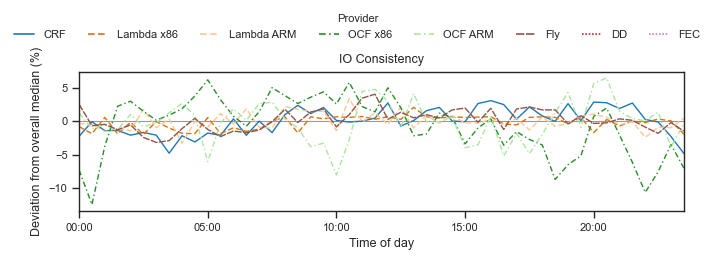

In [56]:
# CPU + IO 15-minute deviation from overall median (shared legend)
from pathlib import Path
import json
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

sns.set_theme(
    context="paper",
    style="ticks",
    rc={
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "legend.title_fontsize": 8,
    },
)

def _safe_name(text: str) -> str:
    return text.replace(" ", "_").replace("/", "-").replace("+", "plus").lower()

providers = ["google", "awsX86", "awsARM", "oracleX86", "oracleARM", "flyio", "deno", "fastly"]  # <-- edit this list

config_path = Path("config") / "provider_config.json"
with config_path.open("r", encoding="utf-8") as f:
    provider_config = json.load(f)

provider_labels = provider_config["provider_labels"]
provider_palette = provider_config["provider_palette"]
provider_linestyles = provider_config.get("provider_linestyles", {})

_dash_lookup = {
    "solid": (),
    "dashed": (4, 2),
    "dashdot": (4, 2, 1, 2),
    "dotted": (1, 1),
}

def _dash_from_config(value):
    if isinstance(value, list):
        return tuple(value)
    if isinstance(value, tuple):
        return value
    if isinstance(value, str):
        return _dash_lookup.get(value, ())
    return ()

def _legend_linestyle(dashes: tuple):
    return (0, dashes) if dashes else "solid"

def _blend_color(hex_color: str, target: tuple[float, float, float], amount: float) -> str:
    base = mcolors.to_rgb(hex_color)
    blended = tuple((1 - amount) * c + amount * t for c, t in zip(base, target))
    return mcolors.to_hex(blended)

def _tint(hex_color: str, amount: float = 0.25) -> str:
    return _blend_color(hex_color, (1.0, 1.0, 1.0), amount)

def _shade(hex_color: str, amount: float = 0.2) -> str:
    return _blend_color(hex_color, (0.0, 0.0, 0.0), amount)

dash_map = {
    p: _dash_from_config(provider_linestyles.get(p, "solid"))
    for p in providers
}

# Consistent color mapping across figures (with distinct light/dark for same linestyle pairs)
provider_colors = {p: provider_palette.get(p, "#999999") for p in providers}

if "awsX86" in provider_colors and "awsARM" in provider_colors:
    base = provider_palette.get("awsX86", provider_colors["awsX86"])
    provider_colors["awsX86"] = _shade(base, 0.12)
    provider_colors["awsARM"] = _tint(provider_palette.get("awsARM", base), 0.18)
if "oracleX86" in provider_colors and "oracleARM" in provider_colors:
    base = provider_palette.get("oracleX86", provider_colors["oracleX86"])
    provider_colors["oracleX86"] = _shade(base, 0.12)
    provider_colors["oracleARM"] = _tint(provider_palette.get("oracleARM", base), 0.18)

def _load_experiment_df(experiment: str) -> pd.DataFrame:
    df = pd.read_sql("select * from data where experiment = ?", cnx, params=[experiment])
    df = df[df["provider"].isin(providers)].copy()
    # Preserve full timestamp to extract time-of-day bins
    df["date_time"] = pd.to_datetime(
        df["date_time"],
        format="%Y-%m-%dT%H-%M-%S",
        errors="coerce",
    )
    df = df.dropna(subset=["date_time"]).copy()
    # Cap outliers per provider (p99)
    df["p99"] = df.groupby("provider")["time_to_complete"].transform(lambda s: s.quantile(0.99))
    df = df[df["time_to_complete"] <= df["p99"]].drop(columns=["p99"])

    return df

df_io = _load_experiment_df("io")

# Use microseconds (µs)
df_io["time_µs"] = df_io["time_to_complete"]

# Aggregate by 30-minute bins (0-1439 minutes)
df_io["minute_of_day"] = df_io["date_time"].dt.hour * 60 + df_io["date_time"].dt.minute
df_io["bin_minute"] = (df_io["minute_of_day"] // 30) * 30
bin_order = list(range(0, 24 * 60, 30))
tick_minutes = list(range(0, 24 * 60, 300))
tick_labels = [f"{m // 60:02d}:{m % 60:02d}" for m in tick_minutes]
df_io["bin_minute"] = pd.Categorical(df_io["bin_minute"], categories=bin_order, ordered=True)

# Overall median per provider (constant across bins)
io_overall = (
    df_io.groupby("provider", as_index=False)["time_µs"]
    .median()
    .rename(columns={"time_µs": "overall_median"})
)

# Median per 30-minute bin per provider
io_binned = (
    df_io.groupby(["bin_minute", "provider"], as_index=False)["time_µs"]
    .median()
    .rename(columns={"time_µs": "bin_median"})
)

# Percent deviation from overall median
io_binned = io_binned.merge(io_overall, on="provider", how="left")
io_binned["pct_deviation"] = (
    (io_binned["bin_median"] - io_binned["overall_median"])
    / io_binned["overall_median"]
    * 100
)

fig, ax_io = plt.subplots(nrows=1, ncols=1, figsize=(6.8, 2.4))

sns.lineplot(
    data=io_binned,
    x="bin_minute",
    y="pct_deviation",
    hue="provider",
    style="provider",
    dashes=dash_map,
    hue_order=providers,
    style_order=providers,
    palette=provider_colors,
    ax=ax_io,
    linewidth=1.0,
    legend=False,
 )
ax_io.set_title("IO Consistency")
ax_io.set_ylabel("Deviation from overall median (%)")
ax_io.set_xlabel("Time of day")
ax_io.set_xlim(0, 23 * 60 + 30)
ax_io.set_xticks(tick_minutes)
ax_io.set_xticklabels(tick_labels)
ax_io.set_yscale("linear")
ax_io.axhline(0, color="#999999", linewidth=0.8, zorder=0)

legend_handles = [
    Line2D([0], [0], color=provider_colors[p], lw=1.2, linestyle=_legend_linestyle(dash_map.get(p, ())))
    for p in providers
 ]
legend_labels = [provider_labels.get(p, p) for p in providers]
fig.legend(
    legend_handles,
    legend_labels,
    title="Provider",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=len(providers),
    frameon=False,
    handlelength=1.8
)

fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# Export camera-ready version (no title)
export_dir = Path("figures") / "04_cpu"
export_dir.mkdir(parents=True, exist_ok=True)
export_path = export_dir / f"cpu_io_latency_all_providers_{_safe_name('30min_deviation_pct')}.pdf"
fig.savefig(export_path, bbox_inches="tight")
plt.close(fig)

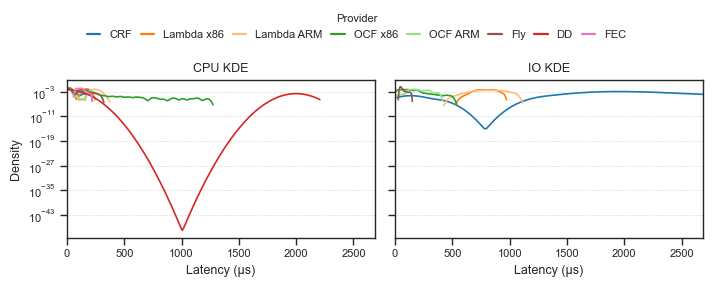

In [49]:
# KDE: CPU and IO latency (all providers overlaid, two subplots)
from pathlib import Path
import json

providers = ["google", "awsX86", "awsARM", "oracleX86", "oracleARM", "flyio", "deno", "fastly"]  # <-- edit this list

config_path = Path("config") / "provider_config.json"
with config_path.open("r", encoding="utf-8") as f:
    provider_config = json.load(f)

provider_labels = provider_config["provider_labels"]
provider_palette = provider_config["provider_palette"]
provider_colors = {p: provider_palette.get(p, "#999999") for p in providers}

def _load_experiment_df(experiment: str) -> pd.DataFrame:
    df = pd.read_sql("select * from data where experiment = ?", cnx, params=[experiment])
    df = df[df["provider"].isin(providers)].copy()
    # Cap outliers per provider (p99)
    df["p99"] = df.groupby("provider")["time_to_complete"].transform(lambda s: s.quantile(0.99))
    df = df[df["time_to_complete"] <= df["p99"]].drop(columns=["p99"])

    return df

df_cpu = _load_experiment_df("cpu")
df_io = _load_experiment_df("io")

df_cpu["time_µs"] = df_cpu["time_to_complete"] * 1000
df_io["time_µs"] = df_io["time_to_complete"]

x_max = max(df_cpu["time_µs"].quantile(0.99), df_io["time_µs"].quantile(0.99))

fig, (ax_cpu, ax_io) = plt.subplots(nrows=1, ncols=2, figsize=(7.2, 2.6), sharey=True)

for provider in providers:
    color = provider_colors.get(provider, "#999999")
    df_cpu_p = df_cpu[df_cpu["provider"] == provider]
    df_io_p = df_io[df_io["provider"] == provider]
    if not df_cpu_p.empty:
        sns.kdeplot(
            data=df_cpu_p,
            x="time_µs",
            bw_adjust=1.0,
            color=color,
            ax=ax_cpu,
        )
    if not df_io_p.empty:
        sns.kdeplot(
            data=df_io_p,
            x="time_µs",
            bw_adjust=1.0,
            color=color,
            ax=ax_io,
        )

ax_cpu.set_title("CPU KDE")
ax_io.set_title("IO KDE")
ax_cpu.set_xlabel("Latency (µs)")
ax_io.set_xlabel("Latency (µs)")
ax_cpu.set_ylabel("Density")
ax_io.set_ylabel("")
ax_cpu.set_yscale("log", nonpositive="clip")
ax_io.set_yscale("log", nonpositive="clip")
ax_cpu.set_xlim(0, x_max)
ax_io.set_xlim(0, x_max)
ax_cpu.grid(True, axis="y", linestyle=":", linewidth=0.6, color="#cccccc")
ax_io.grid(True, axis="y", linestyle=":", linewidth=0.6, color="#cccccc")

legend_handles = [
    Line2D([0], [0], color=provider_colors[p], lw=1.6)
    for p in providers
]
legend_labels = [provider_labels.get(p, p) for p in providers]
fig.legend(
    legend_handles,
    legend_labels,
    title="Provider",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=len(providers),
    frameon=False,
    handlelength=1.2,
    columnspacing=0.8,
    borderaxespad=0.0,
 )

fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

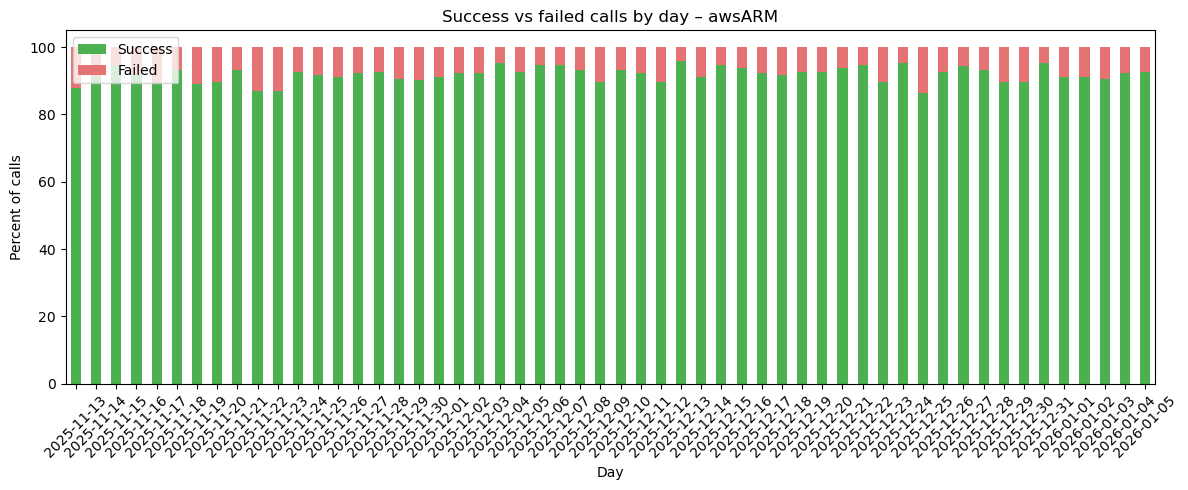

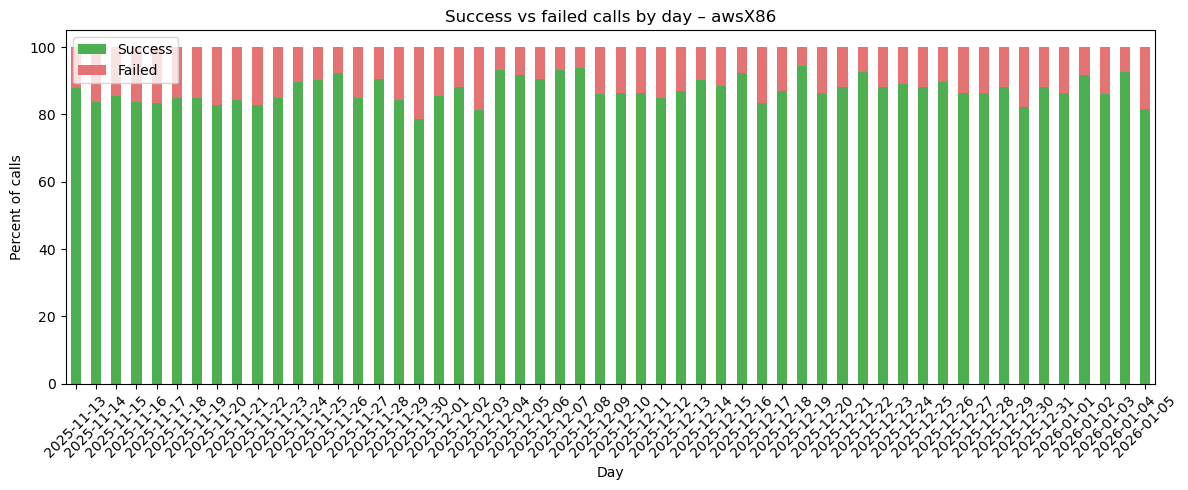

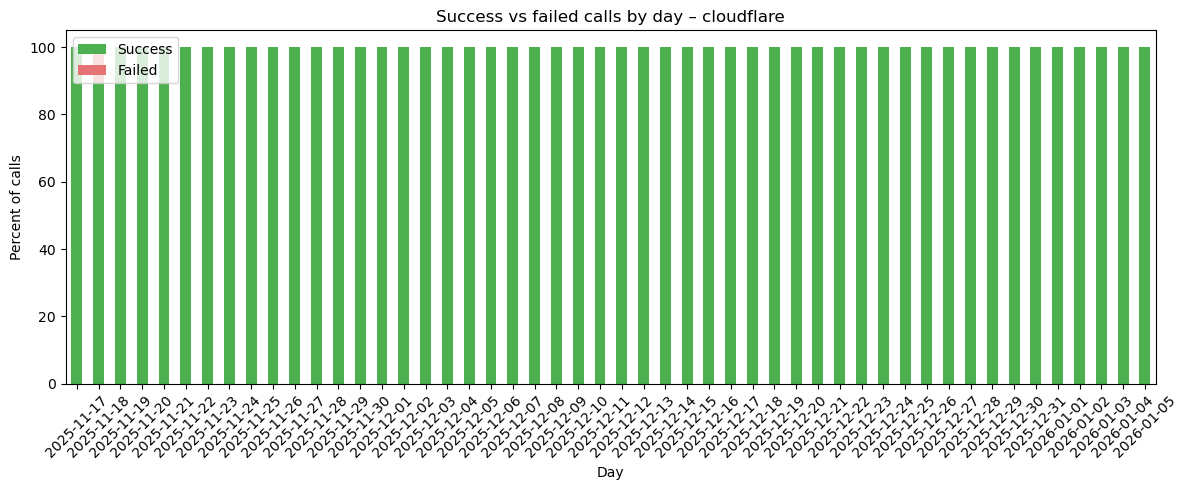

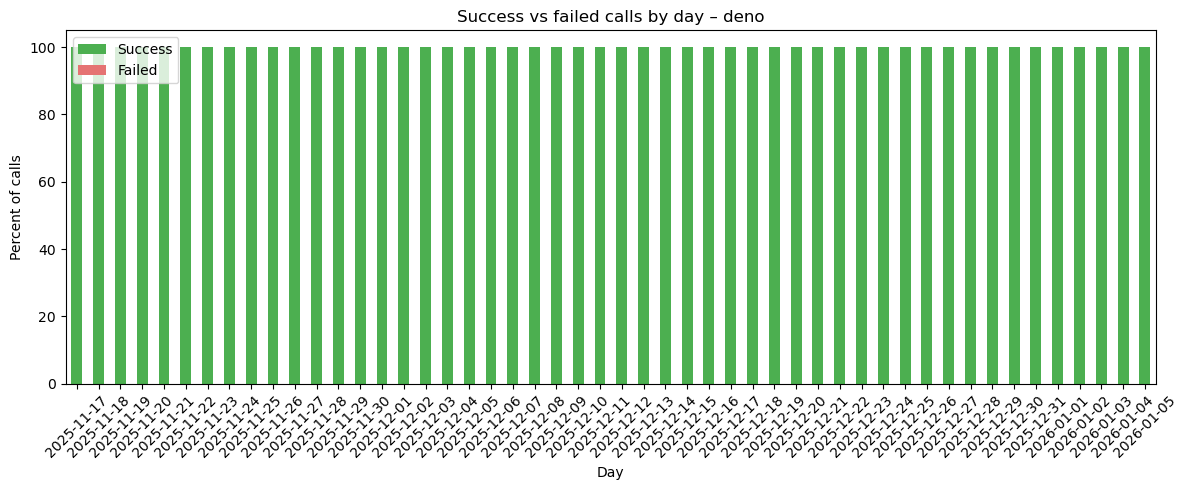

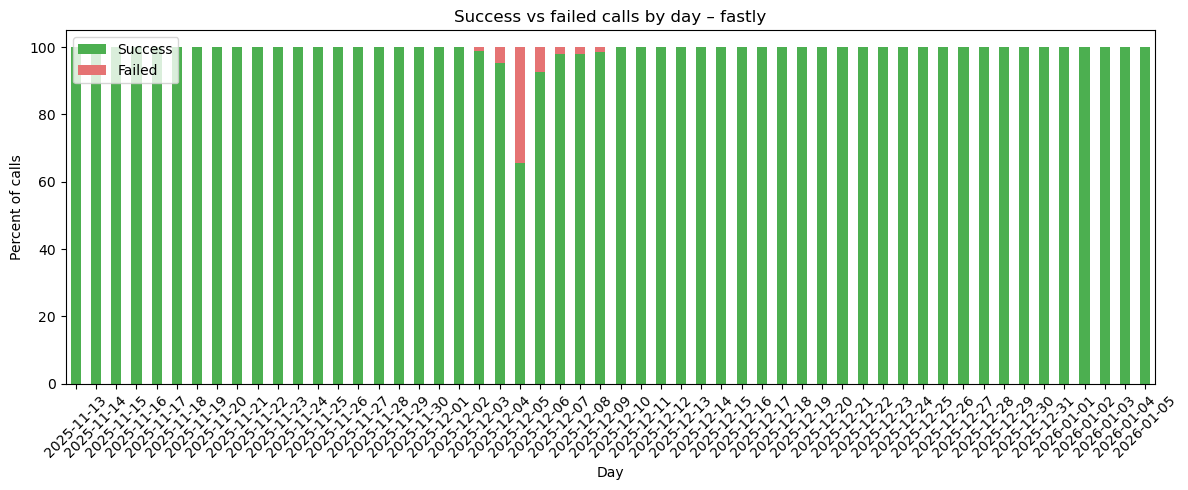

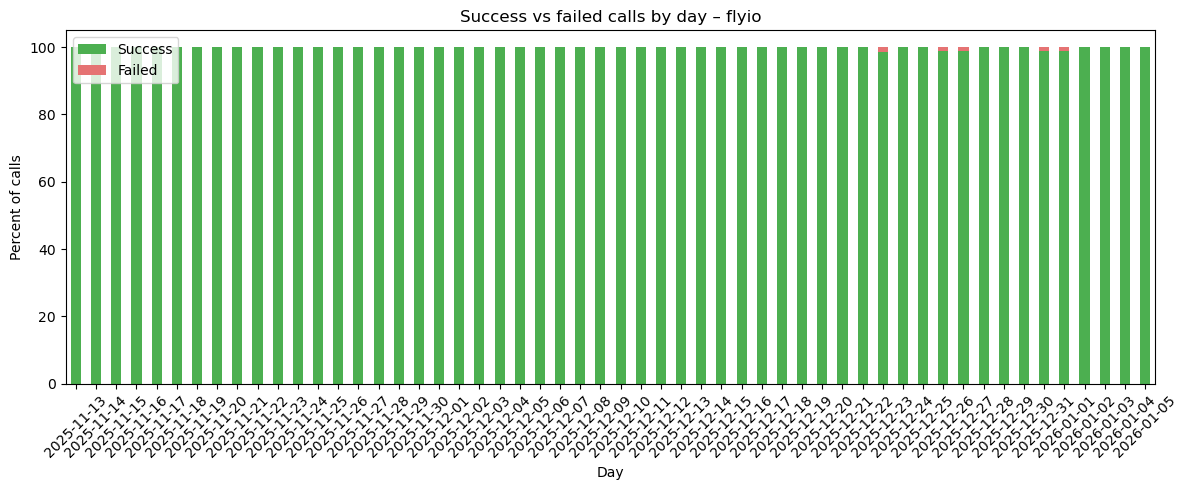

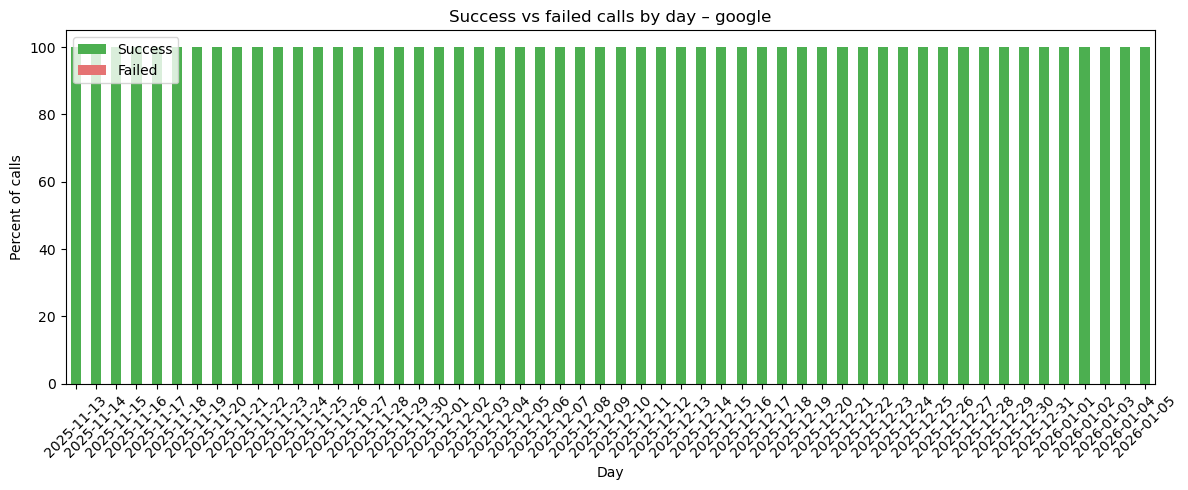

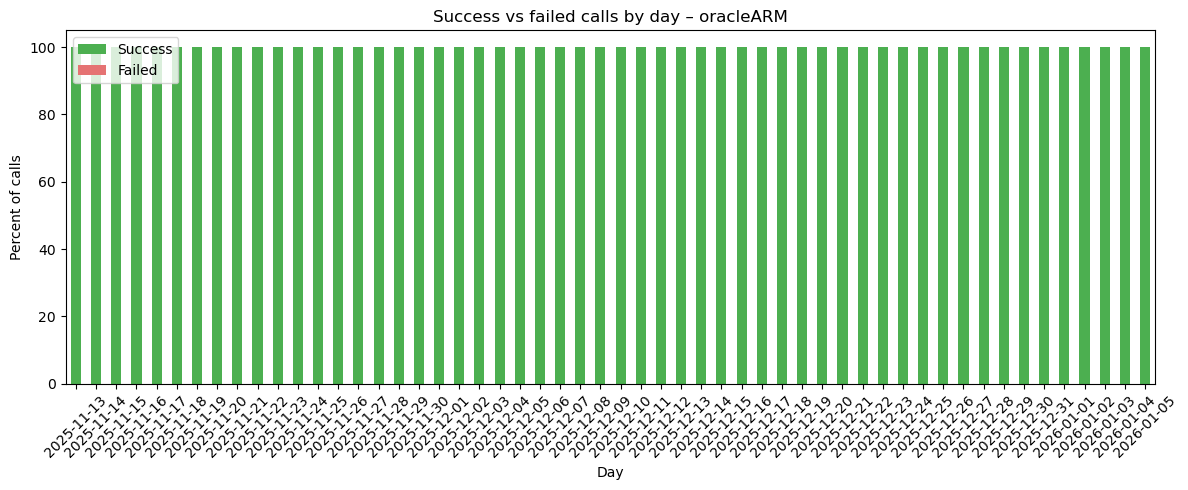

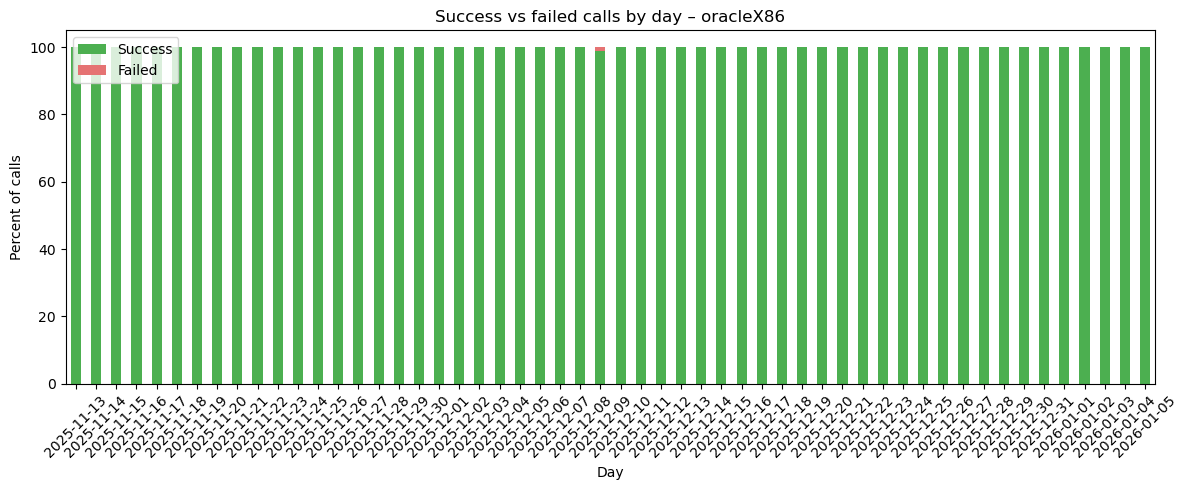

In [31]:
# Check missing data per day with success vs failure ratios (one chart per provider)

# Total calls per day/provider
df_total = pd.read_sql_query("""
    SELECT
        substr(date_time, 1, 10) AS day,
        provider,
        COUNT(*) AS total_count
    FROM data
    WHERE experiment = 'cpu'
    GROUP BY day, provider
""", cnx)

# Missing time_to_complete per day/provider
df_null = pd.read_sql_query("""
    SELECT
        substr(date_time, 1, 10) AS day,
        provider,
        COUNT(*) AS null_count
    FROM data
    WHERE experiment = 'cpu'
      AND time_to_complete IS NULL
    GROUP BY day, provider
""", cnx)

# Merge and compute success/failure counts and percentages
df = df_total.merge(df_null, on=["day", "provider"], how="left")
df["null_count"] = df["null_count"].fillna(0)
df["success_count"] = df["total_count"] - df["null_count"]
df["fail_pct"] = 100.0 * df["null_count"] / df["total_count"]
df["success_pct"] = 100.0 * df["success_count"] / df["total_count"]

providers = sorted(df["provider"].unique())

for provider in providers:
    df_p = df[df["provider"] == provider].copy()
    if df_p.empty:
        continue

    df_p = df_p.sort_values("day")
    plot_df = df_p.set_index("day")[["success_pct", "fail_pct"]]

    # Stacked percentage bars per day for this provider
    plot_df.plot(kind="bar", stacked=True, figsize=(12, 5), color=["#4CAF50", "#E57373"])
    plt.title(f"Success vs failed calls by day – {provider}")
    plt.xlabel("Day")
    plt.ylabel("Percent of calls")
    plt.xticks(rotation=45)
    plt.legend(["Success", "Failed"], loc="upper left")
    plt.tight_layout()
    plt.show()

awsARM Pearson r: 0.295
awsX86 Pearson r: 0.004
flyio Pearson r: 0.286
google Pearson r: 0.154
oracleARM Pearson r: 0.262
oracleX86 Pearson r: 0.773


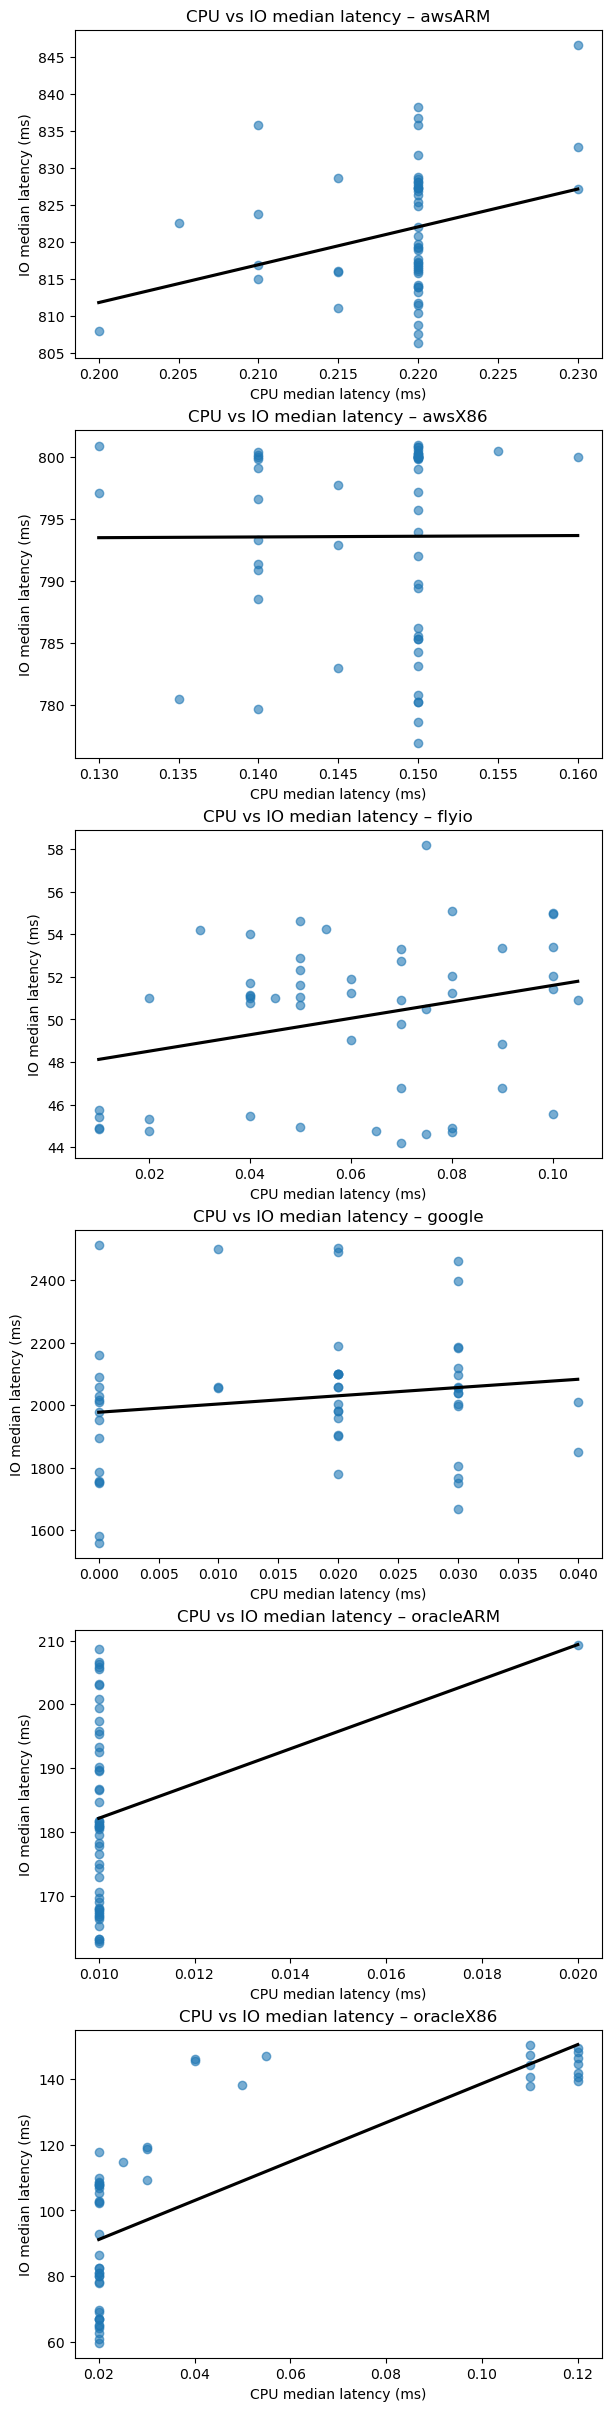

In [4]:
# NEW: Correlation between CPU and IO per provider (daily medians)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load daily medians for cpu and io
cpu_df = pd.read_sql_query(
    """
    SELECT substr(date_time, 1, 10) AS day, provider, time_to_complete
    FROM data
    WHERE experiment = 'cpu' AND time_to_complete IS NOT NULL
    """,
    cnx,
)
io_df = pd.read_sql_query(
    """
    SELECT substr(date_time, 1, 10) AS day, provider, time_to_complete
    FROM data
    WHERE experiment = 'io' AND time_to_complete IS NOT NULL
    """,
    cnx,
)

# Cap outliers per provider using p99 within each experiment (raw)
cpu_df["p99"] = cpu_df.groupby("provider")["time_to_complete"].transform(lambda s: s.quantile(0.99))
cpu_df = cpu_df[cpu_df["time_to_complete"] <= cpu_df["p99"]].drop(columns=["p99"])
io_df["p99"] = io_df.groupby("provider")["time_to_complete"].transform(lambda s: s.quantile(0.99))
io_df = io_df[io_df["time_to_complete"] <= io_df["p99"]].drop(columns=["p99"])

cpu_daily = (
    cpu_df.groupby(["day", "provider"], as_index=False)["time_to_complete"]
    .median()
    .rename(columns={"time_to_complete": "cpu_median"})
)
io_daily = (
    io_df.groupby(["day", "provider"], as_index=False)["time_to_complete"]
    .median()
    .rename(columns={"time_to_complete": "io_median"})
)

merged = cpu_daily.merge(io_daily, on=["day", "provider"], how="inner")
providers = sorted(merged["provider"].unique())

if not providers:
    print("No overlapping CPU/IO data found.")
else:
    n = len(providers)
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(6, 4 * n), constrained_layout=True)
    if n == 1:
        axes = [axes]
    for ax, provider in zip(axes, providers):
        df_p = merged[merged["provider"] == provider].copy()
        if df_p.empty:
            continue
        # Cap p99 on both metrics (daily medians) per provider
        cpu_p99 = df_p["cpu_median"].quantile(0.99)
        io_p99 = df_p["io_median"].quantile(0.99)
        df_p = df_p[(df_p["cpu_median"] <= cpu_p99) & (df_p["io_median"] <= io_p99)]
        corr = df_p["cpu_median"].corr(df_p["io_median"])
        if pd.notna(corr):
            print(f"{provider} Pearson r: {corr:.3f}")
        else:
            print(f"{provider} Pearson r: N/A")
        sns.regplot(
            data=df_p,
            x="cpu_median",
            y="io_median",
            scatter_kws={"alpha": 0.6},
            line_kws={"color": "black"},
            ci=None,
            ax=ax,
        )
        ax.set_title(f"CPU vs IO median latency – {provider}")
        ax.set_xlabel("CPU median latency (ms)")
        ax.set_ylabel("IO median latency (ms)")
    plt.show()